# Momentum Engineering (Notebook)

This notebook mirrors `momentum.py` and adds visual checks at each step.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
BASE_DIR = Path(".")
valid_bookings_df = pd.read_parquet(BASE_DIR / "valid_bookings.parquet")
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,adult,end_time,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason
3,NaN,NaN,NaN,NaN,<NA>,2023-08-13T05:47:00.000000,False,False,False,True,...,1,19:00:00,19:00:00,True,149.93,2025-05-13,1,Tuesday,False,
4,NaN,1.0,0.0,0.0,Web,2023-08-24T12:38:03,False,False,False,True,...,2,19:00:00,19:00:00,True,302.25,2024-06-17,0,Monday,False,
8,NaN,1.0,0.0,0.0,Web,2023-08-26T13:45:03,False,False,False,True,...,3,19:00:00,19:00:00,True,590.36,2024-06-06,3,Thursday,False,
10,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,2,18:00:00,17:00:00,True,199.60,2024-03-28,3,Thursday,False,
11,NaN,1.0,0.0,0.0,iOS,2023-09-25T03:09:57,False,False,False,True,...,7,18:00:00,18:00:00,True,1057.87,2025-12-18,3,Thursday,False,


In [2]:
#remove outliers from restaurant_id based on google sheet 
outlier_ids = [4503, 4502, 933, 837]
valid_bookings_df = valid_bookings_df[~valid_bookings_df['restaurant_id'].isin(outlier_ids)]
valid_bookings_df.shape


(452349, 29)

In [3]:
BASE_PATH = Path.cwd().parent.parent
PARQUET_PATH = BASE_PATH / "data" / "mv_dataset_parquet"
restaurants = pd.read_parquet(PARQUET_PATH / "restaurants.parquet")
restaurants.shape

(2474, 3)

In [4]:
valid_bookings_df = valid_bookings_df.merge(restaurants, on="restaurant_id", how="left")
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,start_time,active,revenue_dollars,booking_date,day_of_week_index,day_of_week,is_outlier,outlier_reason,name,days_in_advance
0,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,17:00:00,True,199.6,2024-03-28,3,Thursday,False,,Vantage Point QSNCC,180.0
1,1.0,NaN,0.0,1.0,Web,2023-10-16T13:37:18,False,False,False,True,...,19:00:00,True,232.8,2024-02-10,5,Saturday,False,,Place Bangkok,90.0
2,NaN,NaN,0.0,0.0,iOS,2023-10-24T14:44:53,False,False,False,True,...,17:00:00,True,1119.8,2024-01-20,5,Saturday,False,,Chatrium Hotel Riverside Bangkok Staycation,90.0
3,1.0,NaN,0.0,0.0,Web,2023-10-25T09:38:08,False,False,False,True,...,14:00:00,True,180.0,2024-03-30,5,Saturday,False,,<NA>,NaN
4,NaN,NaN,0.0,1.0,iOS,2023-10-28T04:42:45,False,False,False,True,...,18:00:00,True,199.6,2024-01-21,6,Sunday,False,,Vantage Point QSNCC,180.0


In [5]:
#retrieve places api data from csv
CSV_PATH = BASE_PATH / "_1_eda" / "places_api_new_results.csv"

# Load the CSV
google_restaurants_df = pd.read_csv(CSV_PATH)
google_restaurants_df.shape

(2392, 12)

In [6]:
valid_bookings_df = valid_bookings_df.merge(google_restaurants_df, left_on='name', right_on='input_string', how='left')
valid_bookings_df.head()

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,official_name,city,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types
0,NaN,NaN,NaN,1.0,Web,2023-09-22T03:57:13,False,False,False,True,...,Vantage Point,NaN,Thailand,ชั้น 2 เลขที่ 60 Queen Sirikit National Conven...,4.2,https://www.facebook.com/VantagePointRestaurante,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int..."
1,1.0,NaN,0.0,1.0,Web,2023-10-16T13:37:18,False,False,False,True,...,place.bangkok,NaN,Thailand,"73/3 ซอย อินทามระ 4 Khwaeng Samsen Nai, Khet P...",4.4,https://www.facebook.com/placebangkok/,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,point_of_interes..."
2,NaN,NaN,0.0,0.0,iOS,2023-10-24T14:44:53,False,False,False,True,...,Chatrium Hotel Riverside Bangkok,NaN,Thailand,"28 ถ. เจริญกรุง Khwaeng Wat Phraya Krai, Khet ...",4.6,https://www.chatrium.com/chatriumriversidebang...,API key not valid. Please pass a valid API key.,NaN,0.20,"hotel,lodging,point_of_interest,establishment"
3,1.0,NaN,0.0,0.0,Web,2023-10-25T09:38:08,False,False,False,True,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,0.0,1.0,iOS,2023-10-28T04:42:45,False,False,False,True,...,Vantage Point,NaN,Thailand,ชั้น 2 เลขที่ 60 Queen Sirikit National Conven...,4.2,https://www.facebook.com/VantagePointRestaurante,API key not valid. Please pass a valid API key.,General,0.15,"buffet_restaurant,restaurant,food,point_of_int..."


In [7]:
# 1. Create a deep copy to avoid SettingWithCopy warnings
clean_bookings_df = valid_bookings_df.copy()

# 2. Count before for your records
initial_count = len(clean_bookings_df)
print (f"Initial records: {initial_count}")

# 3. Drop records where user_id_masked is an empty string or NaN
clean_bookings_df = clean_bookings_df[
    (clean_bookings_df['user_id_masked'] != "") & 
    (clean_bookings_df['user_id_masked'].notna())
]

# 4. Verification
removed_count = initial_count - len(clean_bookings_df)
print(f"Removed {removed_count} records with empty or null user_id_masked.")
print(f"Remaining records: {len(clean_bookings_df)}")

Initial records: 452349
Removed 135856 records with empty or null user_id_masked.
Remaining records: 316493


In [8]:
# The 'Gold Standard' for identifying these specific system duplicates
logic_columns = [
    'user_id_masked', 
    'restaurant_id', 
    'booking_date', 
    'start_time', 
    'end_time', 
    'active'
]

# Identify the duplicates
duplicate_mask = clean_bookings_df.duplicated(subset=logic_columns, keep=False)
duplicates_only = clean_bookings_df[duplicate_mask].sort_values(by=['user_id_masked', 'id'])

# Count them
unique_duplicate_events = duplicates_only.groupby(logic_columns).ngroups

print(f"Identified {unique_duplicate_events} events that have redundant system entries.")

Identified 2720 events that have redundant system entries.


In [9]:
# Select only the identifying columns to verify they are identical
verification_cols = ['id', 'user_id_masked', 'restaurant_id', 'booking_date', 'start_time', 'end_time', 'revenue_dollars', 'active']

# View the top 20 duplicates with these specific columns
duplicates_only[verification_cols].head(20)

,id,user_id_masked,restaurant_id,booking_date,start_time,end_time,revenue_dollars,active
279293,7485531,10004982607977776954,894,2025-05-11,13:00:00,15:00:00,226.40,True
279295,7485538,10004982607977776954,894,2025-05-11,13:00:00,15:00:00,136.00,True
163625,6392572,1002398865849034957,2592,2024-11-13,18:00:00,18:00:00,1099.00,True
163630,6392601,1002398865849034957,2592,2024-11-13,18:00:00,18:00:00,769.30,True
327266,7755687,10038524973759102977,4385,2025-07-26,18:00:00,20:00:00,76.56,True
327276,7755712,10038524973759102977,4385,2025-07-26,18:00:00,20:00:00,76.56,True
81665,5264161,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
81667,5264174,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
81668,5264186,10049410200564458075,3279,2024-07-07,12:00:00,12:00:00,99.90,True
236,3991557,10050903249521646579,2001,2024-02-04,12:00:00,14:00:00,1505.00,True


In [10]:
# We sort by ID descending so the highest ID appears first for each group
final_bookings_df = clean_bookings_df.sort_values('id', ascending=False).drop_duplicates(
    subset=logic_columns, 
    keep='first'
)

In [11]:
# Calculate the IDs that were removed (the "old_transaction_ids")
all_ids = set(clean_bookings_df['id'])
kept_ids = set(final_bookings_df['id'])
old_transaction_ids = list(all_ids - kept_ids)

print(f"Original Records: {len(clean_bookings_df)}")
print(f"Cleaned Records: {len(final_bookings_df)}")
print(f"Total 'Old' IDs identified for deletion: {len(old_transaction_ids)}")

Original Records: 316493
Cleaned Records: 313276
Total 'Old' IDs identified for deletion: 3149


In [12]:
final_bookings_df['country'].value_counts()

country
Thailand           241311
Singapore            3315
United States         350
Hong Kong             230
France                205
Malaysia              121
India                  48
Indonesia              21
Canada                 20
Netherlands            19
United Kingdom         13
Nigeria                10
North Macedonia        10
Brazil                  8
Italy                   8
Japan                   8
Australia               7
Vietnam                 6
Greece                  3
New Zealand             1
Portugal                1
Name: count, dtype: int64

In [13]:
# Filter the DataFrame to strictly keep 'Thailand'
final_bookings_df = final_bookings_df[final_bookings_df['country'] == 'Thailand']

# 3. Verify the filter worked
print("\n--- After Filtering ---")
print(final_bookings_df['country'].value_counts())


--- After Filtering ---
country
Thailand    241311
Name: count, dtype: int64


## 0) Guardrails / required cols

In [14]:
import pandas as pd
import numpy as np
import requests

# 1. Setup Currency Reference
country_to_currency = {
    'Thailand': 'THB', 'Singapore': 'SGD', 'Malaysia': 'MYR',
    'United States': 'USD', 'Japan': 'JPY', 'Hong Kong': 'HKD',
    'United Kingdom': 'GBP', 'Australia': 'AUD', 'Vietnam': 'VND',
    'Indonesia': 'IDR', 'India': 'INR', 'France': 'EUR',
    'Italy': 'EUR', 'Netherlands': 'EUR'
}

# 2. Fetch Live Rates (Base currency is now THB)
def get_live_rates(base_currency='THB'):
    url = f"https://open.er-api.com/v6/latest/{base_currency}"
    try:
        response = requests.get(url)
        data = response.json()
        if data['result'] == 'success':
            return data['rates']
    except Exception as e:
        print(f"API Error: {e}")
        
    # Fallback to approx rates (1 THB = X Target Currency)
    print("Using fallback rates...")
    return {
        'THB': 1.0, 'SGD': 0.038, 'MYR': 0.13, 
        'JPY': 4.2, 'USD': 0.028, 'EUR': 0.026
    }

# Get rates relative to THB
exchange_rates_to_thb = get_live_rates('THB')

# 3. Clean and Validate DataFrame
required_cols = ["restaurant_id", "booking_date", "id", "revenue_dollars", "country"]
missing = [c for c in required_cols if c not in final_bookings_df.columns]
if missing:
    raise ValueError(f"final_bookings_df missing required columns: {missing}")

# Handle Dates and NaNs
final_bookings_df["booking_date"] = pd.to_datetime(final_bookings_df["booking_date"], errors="coerce")
final_bookings_df = final_bookings_df.dropna(subset=["booking_date", "restaurant_id"])

# 4. Apply Currency Conversion (To THB)
def perform_conversion_to_thb(row):
    country = row.get('country')
    amount = row.get('revenue_dollars') # Assuming this column actually holds the raw local currency
    
    currency_code = country_to_currency.get(country)
    
    if currency_code and pd.notnull(amount):
        # The API returns "1 THB = X Local Currency"
        # Example: 1 THB = 1 THB (rate is 1.0)
        # To convert Local to THB: amount / rate
        rate = exchange_rates_to_thb.get(currency_code)
        if rate:
            return amount / rate
            
    return amount

# Rename the output column to reflect the new currency
final_bookings_df["revenue_thb"] = final_bookings_df.apply(perform_conversion_to_thb, axis=1)

# 5. Handle Guest Logic
if "total_guests" not in final_bookings_df.columns:
    if "adult" in final_bookings_df.columns and "kids" in final_bookings_df.columns:
        final_bookings_df["total_guests"] = (
            final_bookings_df["adult"].fillna(0) + final_bookings_df["kids"].fillna(0)
        )
    else:
        final_bookings_df["total_guests"] = np.nan

print(f"Final Shape: {final_bookings_df.shape}")

Final Shape: (241311, 45)


In [15]:
final_bookings_df.head(10)

,has_promptpay,has_cc,has_shopee_pay,has_special_request,medium,created_at,prepared,refund,adjusted,ack,...,country,formatted_address,rating,website,error,Cuisine,Cuisine_confidence,raw_types,revenue_thb,total_guests
452348,NaN,NaN,0.0,0.0,Android,2026-01-07T04:50:49,False,False,False,True,...,Thailand,"B Floor, Banyan Tree Bangkok, 21/100 S Sathon ...",4.6,https://www.banyantree.com/thailand/bangkok/di...,API key not valid. Please pass a valid API key.,Thai,0.70,"buffet_restaurant,thai_restaurant,asian_restau...",79.90,1
452346,NaN,NaN,0.0,0.0,iOS,2026-01-07T04:50:12,False,False,False,True,...,Thailand,"Siphya, 2 ถ. เจริญกรุง แขวงบางรัก เขตบางรัก กร...",4.5,https://www.marriott.com/en-us/dining/restaura...,API key not valid. Please pass a valid API key.,Italian,0.70,"italian_restaurant,restaurant,food,point_of_in...",139.00,2
452343,NaN,NaN,0.0,0.0,Web,2026-01-07T04:47:17,False,False,False,True,...,Thailand,"Kimpton Maa-Lai Bangkok, Soi Ton Son, Khwaeng ...",4.7,https://bit.ly/GGStockRoom,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,food,point_of_interest,establishment",198.00,2
452340,1.0,NaN,0.0,0.0,iOS,2026-01-07T04:46:48,False,False,False,True,...,Thailand,"55 ถนน ศรีนครินทร์ Khwaeng Nong Bon, Khet Praw...",4.7,http://www.boontongkeethailand.com/home/out-ou...,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,food,point_of_interest,establishment",138.00,4
452338,1.0,NaN,0.0,0.0,Android,2026-01-07T04:45:14,False,False,False,True,...,Thailand,"Queen Sirikit National Convention Center, 60 T...",4.1,https://foa.co.th/,API key not valid. Please pass a valid API key.,Chinese,0.70,"chinese_restaurant,restaurant,point_of_interes...",352.50,4
452336,NaN,1.0,0.0,0.0,iOS,2026-01-07T04:43:41,False,False,False,True,...,Thailand,"1 Rachadaphisek Road, Fortune Town, แขวงดินแดง...",4.4,NaN,API key not valid. Please pass a valid API key.,Chinese,0.70,"chinese_restaurant,restaurant,food,point_of_in...",95.88,1
452334,NaN,NaN,0.0,0.0,iOS,2026-01-07T04:41:50,False,False,False,True,...,Thailand,"166, 1-5 ถนน รัชดา 10 Khwaeng Huai Khwang, Khe...",4.4,https://www.facebook.com/kuangseafood2,API key not valid. Please pass a valid API key.,Seafood,0.70,"seafood_restaurant,restaurant,point_of_interes...",912.00,8
452332,NaN,1.0,0.0,0.0,iOS,2026-01-07T04:38:50,False,False,False,True,...,Thailand,เลขที่ 9/8-9 Kagonoya ชั้น 7 ห้อง 730 Thanon R...,3.3,https://m.facebook.com/kagonoyathailand,API key not valid. Please pass a valid API key.,Japanese,0.70,"japanese_restaurant,restaurant,food,point_of_i...",388.50,5
452331,NaN,NaN,0.0,0.0,Android,2026-01-07T04:37:46,False,False,False,True,...,Thailand,"24th floor, Centara Grand and Bangkok Conventi...",4.3,https://www.ventisibangkok.com/,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,point_of_interest,food,establishment",792.00,8
452330,NaN,NaN,0.0,0.0,Web,2026-01-07T04:35:34,False,False,False,True,...,Thailand,"Ground Level Chatrium 728 Thanon Phetchaburi, ...",4.7,https://www.chatrium.com/grandbangkok/savio,API key not valid. Please pass a valid API key.,General,0.15,"restaurant,point_of_interest,food,establishment",225.00,3


In [16]:
final_bookings_df.columns

Index(['has_promptpay', 'has_cc', 'has_shopee_pay', 'has_special_request',
       'medium', 'created_at', 'prepared', 'refund', 'adjusted', 'ack', 'id',
       'restaurant_id', 'is_temporary', 'for_locking_system', 'no_show',
       'arrived', 'channel', 'user_id_masked', 'kids', 'adult', 'end_time',
       'start_time', 'active', 'revenue_dollars', 'booking_date',
       'day_of_week_index', 'day_of_week', 'is_outlier', 'outlier_reason',
       'name', 'days_in_advance', 'input_string', 'found', 'official_name',
       'city', 'country', 'formatted_address', 'rating', 'website', 'error',
       'Cuisine', 'Cuisine_confidence', 'raw_types', 'revenue_thb',
       'total_guests'],
      dtype='object')

In [17]:
final_bookings_df.to_parquet("valid_bookings_with_currency_and_google_restaurants_without_duplicates.parquet")

## 1) Monthly aggregation

In [18]:
final_bookings_df["year_month"] = final_bookings_df["booking_date"].dt.to_period("M").dt.to_timestamp()

# Filter out advance bookings beyond Jan 2026
cutoff_month = pd.Timestamp("2026-01-31")
final_bookings_df = final_bookings_df[final_bookings_df["year_month"] <= cutoff_month].copy()

restaurants_agg = (
    final_bookings_df
    .groupby(["restaurant_id", "name", "year_month"], as_index=False)  # restaurant_id added for downstream join
    .agg(
        monthly_bookings        =("id",           "count"),
        monthly_revenue         =("revenue_thb",  "sum"),
        avg_revenue_per_booking =("revenue_thb",  "mean"),
        avg_guests              =("total_guests",  "mean"),
        active_days             =("booking_date",  lambda x: x.dt.date.nunique()),
    )
)

restaurants_agg["monthly_bookings"] = restaurants_agg["monthly_bookings"].fillna(0).astype(int)
restaurants_agg["monthly_revenue"]  = restaurants_agg["monthly_revenue"].fillna(0.0)
restaurants_agg["avg_revenue_per_booking"] = (
    restaurants_agg["avg_revenue_per_booking"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0.0)
)

restaurants_agg = restaurants_agg.sort_values(["name", "year_month"]).reset_index(drop=True)
print(f"Aggregated shape: {restaurants_agg.shape}")
print(f"Columns: {restaurants_agg.columns.tolist()}")
restaurants_agg.head()

Aggregated shape: (18430, 8)
Columns: ['restaurant_id', 'name', 'year_month', 'monthly_bookings', 'monthly_revenue', 'avg_revenue_per_booking', 'avg_guests', 'active_days']


,restaurant_id,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days
0,4800,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,3198.4,456.914286,2.285714,6
1,4800,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,21789.1,680.909375,3.406250,19
2,4800,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,12593.7,599.700000,3.000000,17
3,4800,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,15592.2,742.485714,3.714286,11
4,4800,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,10594.7,529.735000,2.650000,14


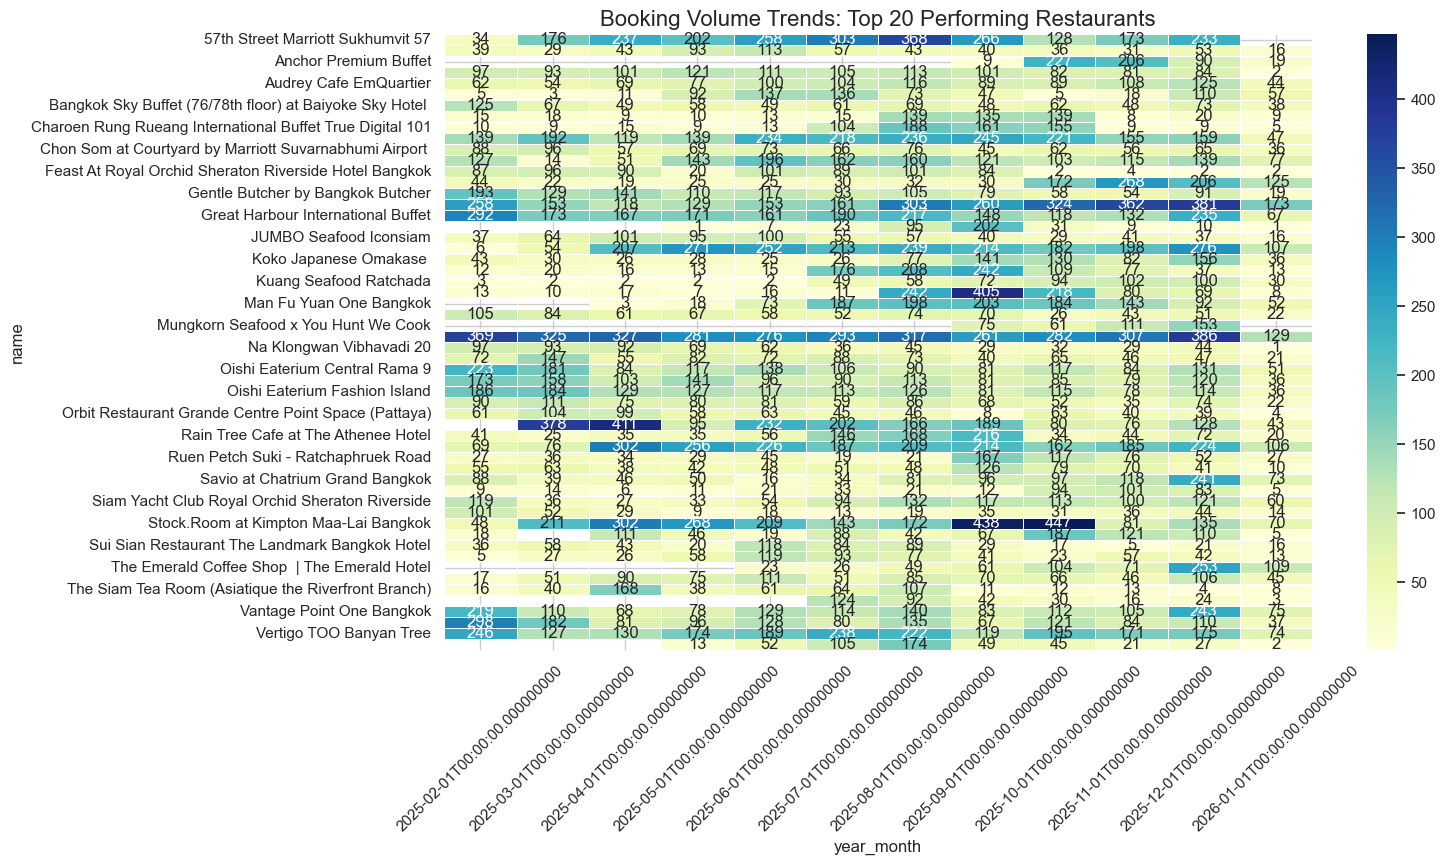

In [19]:
start_date = cutoff_month - pd.DateOffset(months=12)

# 2. Filter for the last 12 months
last_12_months_df = restaurants_agg[
    (restaurants_agg["year_month"] >= start_date) & 
    (restaurants_agg["year_month"] <= cutoff_month)
].copy()

# 3. Extract top 20 for each month
top_20_per_month = (
    last_12_months_df.sort_values(["year_month", "monthly_bookings"], ascending=[True, False])
    .groupby("year_month")
    .head(20)
)

# 1. Get the list of restaurant names that were ever in a Top 20 in the last 12 months
top_restaurants = top_20_per_month['name'].unique()

# 2. Pivot the data: Rows = Restaurants, Cols = Months, Values = Bookings
heatmap_data = last_12_months_df[last_12_months_df['name'].isin(top_restaurants)].pivot(
    index='name', 
    columns='year_month',
    values='monthly_bookings'
)

# 3. Plot
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title("Booking Volume Trends: Top 20 Performing Restaurants", fontsize=16)
plt.xticks(rotation=45)
plt.show()


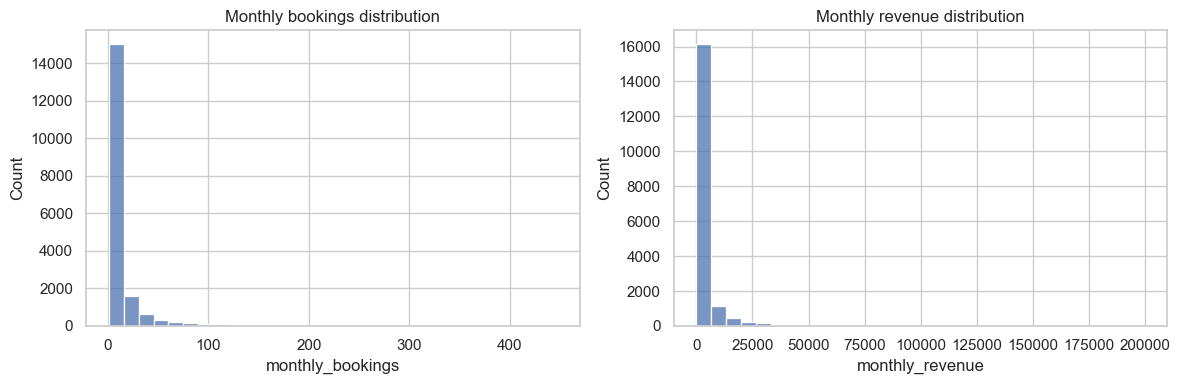

In [20]:
# Plot bookings and revenue distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg["monthly_bookings"], bins=30, ax=axes[0])
axes[0].set_title("Monthly bookings distribution")

sns.histplot(restaurants_agg["monthly_revenue"], bins=30, ax=axes[1])
axes[1].set_title("Monthly revenue distribution")
plt.tight_layout()

## 2) Active Restaurant Filter

We identify which restaurants are **active** (had bookings in the last 12 months) to exclude churned restaurants from scoring.

**Important:** We keep the **full booking history** for active restaurants — not just the last 12 months. This is critical for the YoY seasonality calculation in Step 4, which needs prior-year data (e.g. Jan 2025 data to compute YoY growth for Jan 2026). Truncating to 12 months would leave YoY with no denominator and force everything to fall back to MoM.

In [21]:
# 1. Determine the analysis end date
analysis_end_date = restaurants_agg['year_month'].max()
print(f"Analysis End Date : {analysis_end_date.date()}")

# 2. Define the 12-month activity cutoff
# Restaurants whose LAST record is older than this are considered churned
cutoff_date = analysis_end_date - pd.DateOffset(months=12)
print(f"Activity Cutoff   : {cutoff_date.date()}")
print(f"Data starts from  : {restaurants_agg['year_month'].min().date()}")

# 3. Identify ACTIVE restaurants (had a booking within the last 12 months)
latest_activity   = restaurants_agg.groupby('name')['year_month'].max()
active_restaurants = latest_activity[latest_activity >= cutoff_date].index

# 4. Keep FULL history for active restaurants
# ── WHY: YoY growth for Jan 2026 needs Jan 2025 data.
#         If we truncate to last 12 months, that prior-year data is lost
#         and pct_change(periods=12) returns NaN for almost every row,
#         forcing a fallback to MoM and defeating seasonality adjustment.
restaurants_agg_active = restaurants_agg[
    restaurants_agg['name'].isin(active_restaurants)
].copy()

# 5. Mark which rows fall within the analysis window
# Scoring and segmentation only uses recent rows, but growth calc uses full history
restaurants_agg_active['in_analysis_window'] = (
    restaurants_agg_active['year_month'] >= cutoff_date
)

# 6. Summary
original_count = restaurants_agg['name'].nunique()
new_count      = restaurants_agg_active['name'].nunique()
dropped_count  = original_count - new_count

print(f"\n--- Filter Summary ---")
print(f"Total Restaurants        : {original_count:,}")
print(f"Active (last 12m)        : {new_count:,}")
print(f"Dropped (churned)        : {dropped_count:,}")
print(f"Total rows (full history): {len(restaurants_agg_active):,}")
print(f"Rows in analysis window  : {restaurants_agg_active['in_analysis_window'].sum():,}")
print(f"Prior-year rows retained : {(~restaurants_agg_active['in_analysis_window']).sum():,}  ← needed for YoY")

Analysis End Date : 2026-01-01
Activity Cutoff   : 2025-01-01
Data starts from  : 2024-01-01

--- Filter Summary ---
Total Restaurants        : 1,735
Active (last 12m)        : 1,693
Dropped (churned)        : 42
Total rows (full history): 18,334
Rows in analysis window  : 11,640
Prior-year rows retained : 6,694  ← needed for YoY


In [22]:
restaurants_agg_active

,restaurant_id,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,in_analysis_window
0,4800,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,3198.4,456.914286,2.285714,6,False
1,4800,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,21789.1,680.909375,3.406250,19,False
2,4800,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,12593.7,599.700000,3.000000,17,False
3,4800,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,15592.2,742.485714,3.714286,11,False
4,4800,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,10594.7,529.735000,2.650000,14,True
...,...,...,...,...,...,...,...,...,...
18425,5916,sala ayutthaya staycation (Ayutthaya),2025-06-01,1,468.0,468.000000,2.000000,1,True
18426,5916,sala ayutthaya staycation (Ayutthaya),2025-10-01,1,468.0,468.000000,2.000000,1,True
18427,5917,sala bang pa-in Staycation (Ayutthaya),2025-09-01,2,1560.0,780.000000,3.500000,2,True
18428,5917,sala bang pa-in Staycation (Ayutthaya),2025-10-01,1,2496.0,2496.000000,12.000000,1,True


## 4) Growth, YoY Seasonality-Adjusted Growth & Rolling Growth

**Why year-over-year (YoY)?**
Month-over-month growth is noisy — a restaurant that naturally peaks in December will look like it's declining in January even if it's perfectly healthy. YoY compares each month against the *same month last year*, removing seasonal patterns.

**Fallback logic:**
- Restaurants with ≥12 months of history → use YoY-adjusted growth as primary signal
- Restaurants with <12 months of history → fall back to month-over-month (MoM)
- The rolling 3-month average then smooths whichever signal is used

In [23]:
MAX_GROWTH_CAP = 2.0   # cap at 200% to handle outliers
ROLL = 3               # 3-month rolling window

# ── Step 1: Month-over-month growth (always computed, used as fallback) ───────
restaurants_agg_active["booking_growth_mom"] = (
    restaurants_agg_active.groupby("name")["monthly_bookings"]
    .pct_change()
    .replace([np.inf], MAX_GROWTH_CAP)
    .fillna(0)
    .clip(upper=MAX_GROWTH_CAP, lower=-1.0)
)

restaurants_agg_active["revenue_growth_mom"] = (
    restaurants_agg_active.groupby("name")["monthly_revenue"]
    .pct_change()
    .replace([np.inf], MAX_GROWTH_CAP)
    .fillna(0)
    .clip(upper=MAX_GROWTH_CAP, lower=-1.0)
)

# ── Step 2: Year-over-year growth (same month, prior year) ───────────────────
# pct_change(periods=12) compares Jan-2026 to Jan-2025, Feb-2025 to Feb-2024, etc.
restaurants_agg_active["booking_growth_yoy"] = (
    restaurants_agg_active.groupby("name")["monthly_bookings"]
    .pct_change(periods=12)
    .replace([np.inf], MAX_GROWTH_CAP)
    .clip(upper=MAX_GROWTH_CAP, lower=-1.0)
    # NaN here means <12 months of history — handled in Step 3
)

restaurants_agg_active["revenue_growth_yoy"] = (
    restaurants_agg_active.groupby("name")["monthly_revenue"]
    .pct_change(periods=12)
    .replace([np.inf], MAX_GROWTH_CAP)
    .clip(upper=MAX_GROWTH_CAP, lower=-1.0)
)

# ── Step 3: Flag which restaurants have ≥12 months of history ────────────────
# Because we now keep FULL history (not truncated to 12 months),
# pct_change(periods=12) will find the prior-year row it needs.
# restaurants with data starting after Jan 2025 still won't have
# full YoY coverage — those fall back to MoM as intended.
months_of_history = (
    restaurants_agg_active.groupby("name")["year_month"]
    .nunique()
    .rename("months_of_history")
)
restaurants_agg_active = restaurants_agg_active.merge(
    months_of_history, on="name", how="left"
)
restaurants_agg_active["has_full_year"] = restaurants_agg_active["months_of_history"] >= 12

print(f"Restaurants with ≥12 months history (YoY available): "
      f"{restaurants_agg_active[restaurants_agg_active['has_full_year']]['name'].nunique():,}")
print(f"Restaurants with <12 months history (MoM fallback): "
      f"{restaurants_agg_active[~restaurants_agg_active['has_full_year']]['name'].nunique():,}")

# ── Step 4: Blend — use YoY where available, MoM as fallback ─────────────────
restaurants_agg_active["booking_growth_pct"] = np.where(
    restaurants_agg_active["has_full_year"] & restaurants_agg_active["booking_growth_yoy"].notna(),
    restaurants_agg_active["booking_growth_yoy"],
    restaurants_agg_active["booking_growth_mom"]
)

restaurants_agg_active["revenue_growth_pct"] = np.where(
    restaurants_agg_active["has_full_year"] & restaurants_agg_active["revenue_growth_yoy"].notna(),
    restaurants_agg_active["revenue_growth_yoy"],
    restaurants_agg_active["revenue_growth_mom"]
)

# Flag which signal was used (useful for transparency in output)
restaurants_agg_active["growth_signal_used"] = np.where(
    restaurants_agg_active["has_full_year"] & restaurants_agg_active["booking_growth_yoy"].notna(),
    "YoY", "MoM"
)

print("\nGrowth signal used:")
print(restaurants_agg_active["growth_signal_used"].value_counts())

# ── Step 5: 3-month rolling average of the blended signal ────────────────────
restaurants_agg_active["booking_growth_rolling"] = (
    restaurants_agg_active.groupby("name")["booking_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
    .fillna(0.0)
)

restaurants_agg_active["revenue_growth_rolling"] = (
    restaurants_agg_active.groupby("name")["revenue_growth_pct"]
    .rolling(ROLL, min_periods=ROLL)
    .mean()
    .reset_index(level=0, drop=True)
    .fillna(0.0)
)

restaurants_agg_active[["booking_growth_rolling", "revenue_growth_rolling"]].describe().T

Restaurants with ≥12 months history (YoY available): 683
Restaurants with <12 months history (MoM fallback): 1,010

Growth signal used:
growth_signal_used
MoM    13166
YoY     5168
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
booking_growth_rolling,18334.0,0.179521,0.459045,-0.956552,-0.029027,0.033333,0.402778,2.0
revenue_growth_rolling,18334.0,0.195614,0.468712,-0.941942,-0.028565,0.074159,0.440026,2.0


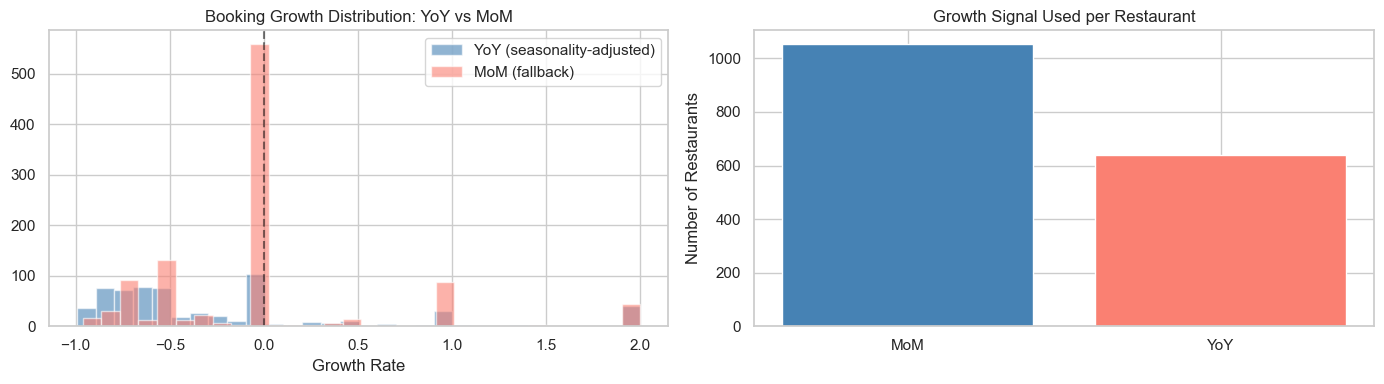

In [24]:
# ── Visualise: YoY vs MoM growth distribution comparison ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Booking growth
latest_snap = restaurants_agg_active.sort_values("year_month").groupby("name").tail(1)

axes[0].hist(
    latest_snap[latest_snap["growth_signal_used"] == "YoY"]["booking_growth_pct"].clip(-1, 2),
    bins=30, alpha=0.6, color="steelblue", label="YoY (seasonality-adjusted)"
)
axes[0].hist(
    latest_snap[latest_snap["growth_signal_used"] == "MoM"]["booking_growth_pct"].clip(-1, 2),
    bins=30, alpha=0.6, color="salmon", label="MoM (fallback)"
)
axes[0].axvline(0, color="black", linestyle="--", alpha=0.5)
axes[0].set_title("Booking Growth Distribution: YoY vs MoM")
axes[0].set_xlabel("Growth Rate")
axes[0].legend()

# Signal used breakdown
signal_counts = latest_snap["growth_signal_used"].value_counts()
axes[1].bar(signal_counts.index, signal_counts.values, color=["steelblue", "salmon"])
axes[1].set_title("Growth Signal Used per Restaurant")
axes[1].set_ylabel("Number of Restaurants")

plt.tight_layout()
plt.show()

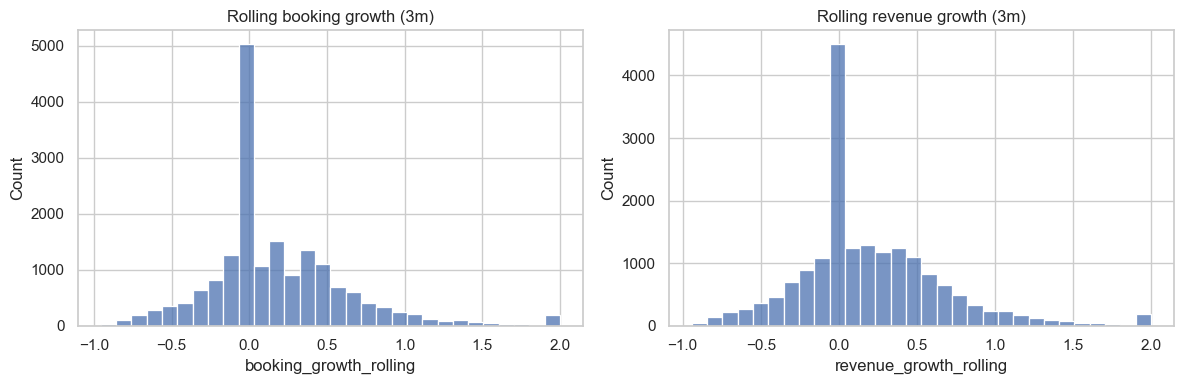

In [25]:
# Growth distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(restaurants_agg_active["booking_growth_rolling"], bins=30, ax=axes[0])
axes[0].set_title("Rolling booking growth (3m)")

sns.histplot(restaurants_agg_active["revenue_growth_rolling"], bins=30, ax=axes[1])
axes[1].set_title("Rolling revenue growth (3m)")
plt.tight_layout()

C:\Users\foogu\AppData\Local\Temp\ipykernel_17836\3796667373.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


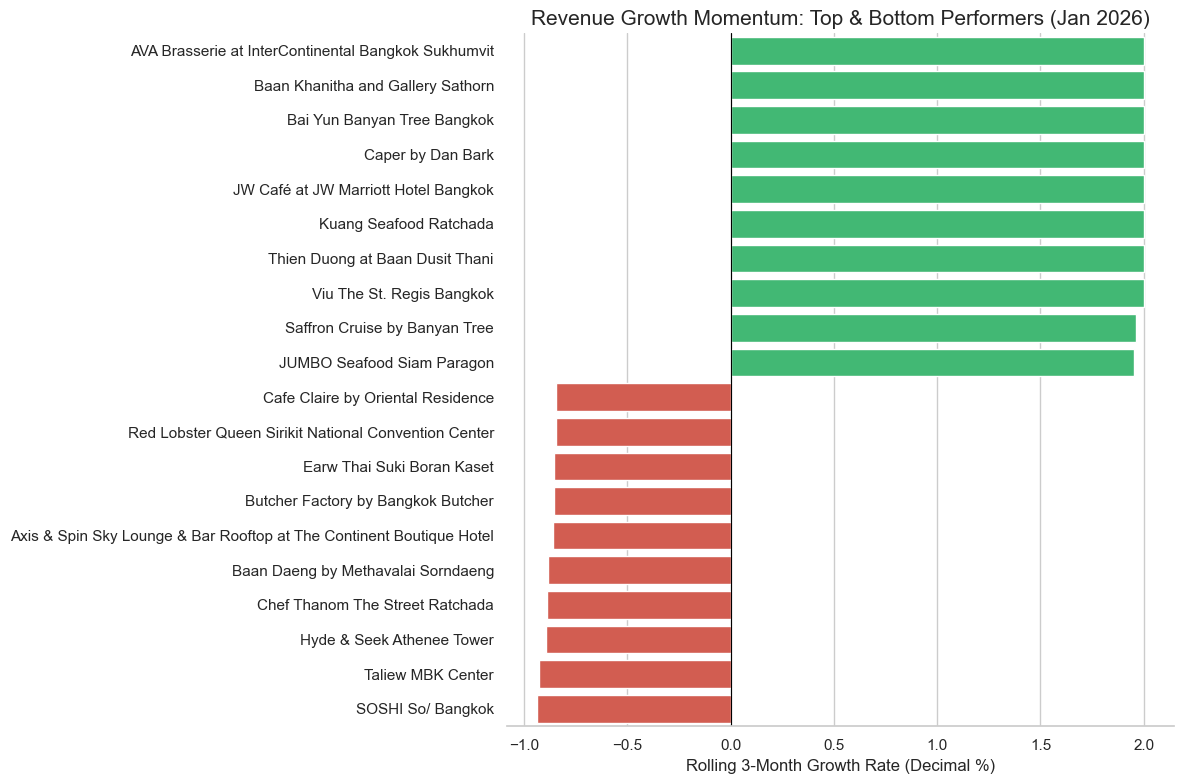

In [26]:
# 1. Get the most recent month's data (Jan 2026)
latest_month_label = restaurants_agg_active['year_month'].max()
latest_growth = restaurants_agg_active[restaurants_agg_active['year_month'] == latest_month_label].copy()

# 2. Identify Top 10 and Bottom 10 by Revenue Growth
top_growth = latest_growth.nlargest(10, "revenue_growth_rolling")
bottom_growth = latest_growth.nsmallest(10, "revenue_growth_rolling")
leaderboard = pd.concat([top_growth, bottom_growth]).sort_values("revenue_growth_rolling", ascending=False)

# 3. Plot
plt.figure(figsize=(12, 8))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in leaderboard['revenue_growth_rolling']]

sns.barplot(
    data=leaderboard,
    x="revenue_growth_rolling",
    y="name",
    palette=colors
)

plt.axvline(0, color='black', linewidth=0.8) # Zero line for reference
plt.title(f"Revenue Growth Momentum: Top & Bottom Performers ({latest_month_label.strftime('%b %Y')})", fontsize=15)
plt.xlabel("Rolling 3-Month Growth Rate (Decimal %)", fontsize=12)
plt.ylabel("")
sns.despine(left=True)
plt.tight_layout()
plt.show()

(233, 8)
Shape after correct merge: (233, 10)


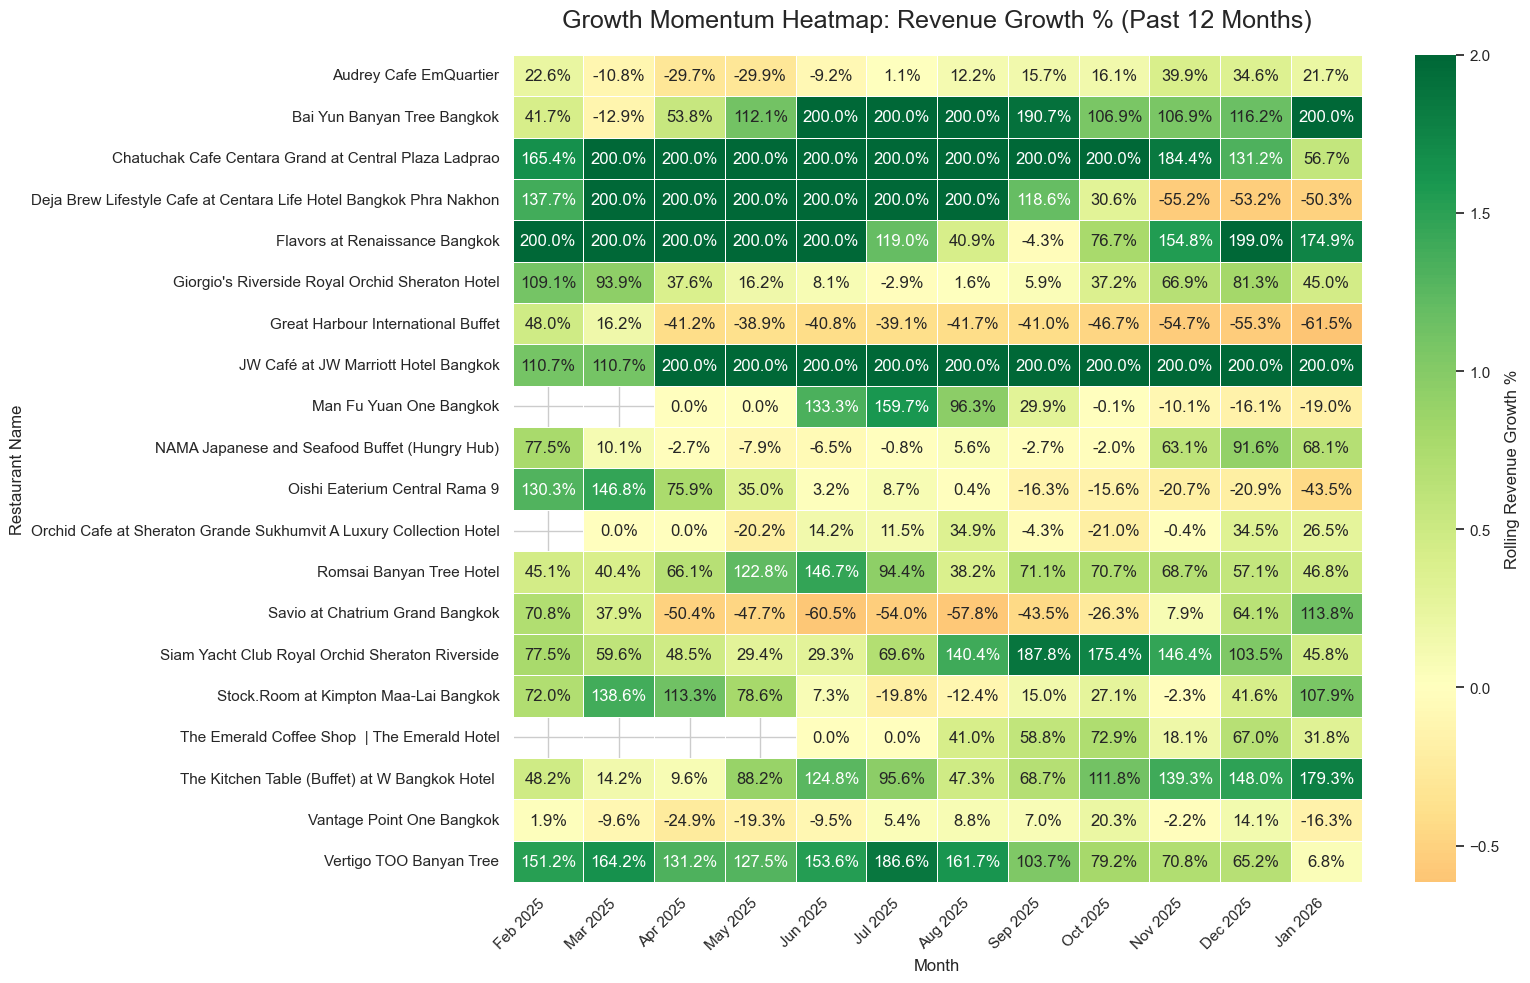

In [27]:
# 1. Filter for the Top 20 restaurants (by latest month volume) 

top_20_names = latest_growth.nlargest(20, "monthly_bookings")["name"].tolist()
growth_trend_df = last_12_months_df[last_12_months_df['name'].isin(top_20_names)]
print(growth_trend_df.shape)


# 2. Pivot the rolling growth data -- growth trend_df does not have the revenue_growth_rolling column yet, so we need to merge it
growth_trend_df = growth_trend_df.merge(
    restaurants_agg_active[['name', 'year_month', 'booking_growth_rolling', 'revenue_growth_rolling']],
    on=['name', 'year_month'],
    how='left'
)

print(f"Shape after correct merge: {growth_trend_df.shape}")

growth_heatmap = growth_trend_df.pivot(
    index='name', 
    columns='year_month', 
    values='revenue_growth_rolling'
)


# 3. Sort chronologically and format labels
growth_heatmap.columns = [d.strftime('%b %Y') for d in growth_heatmap.columns]

# 4. Plot using a Diverging Color Map (RdYlGn: Red-Yellow-Green)
plt.figure(figsize=(16, 10))
sns.heatmap(
    growth_heatmap, 
    annot=True, 
    fmt=".1%", 
    cmap="RdYlGn", 
    center=0, 
    linewidths=.5,
    cbar_kws={'label': 'Rolling Revenue Growth %'}
)

plt.title("Growth Momentum Heatmap: Revenue Growth % (Past 12 Months)", fontsize=18, pad=20)
plt.ylabel("Restaurant Name", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

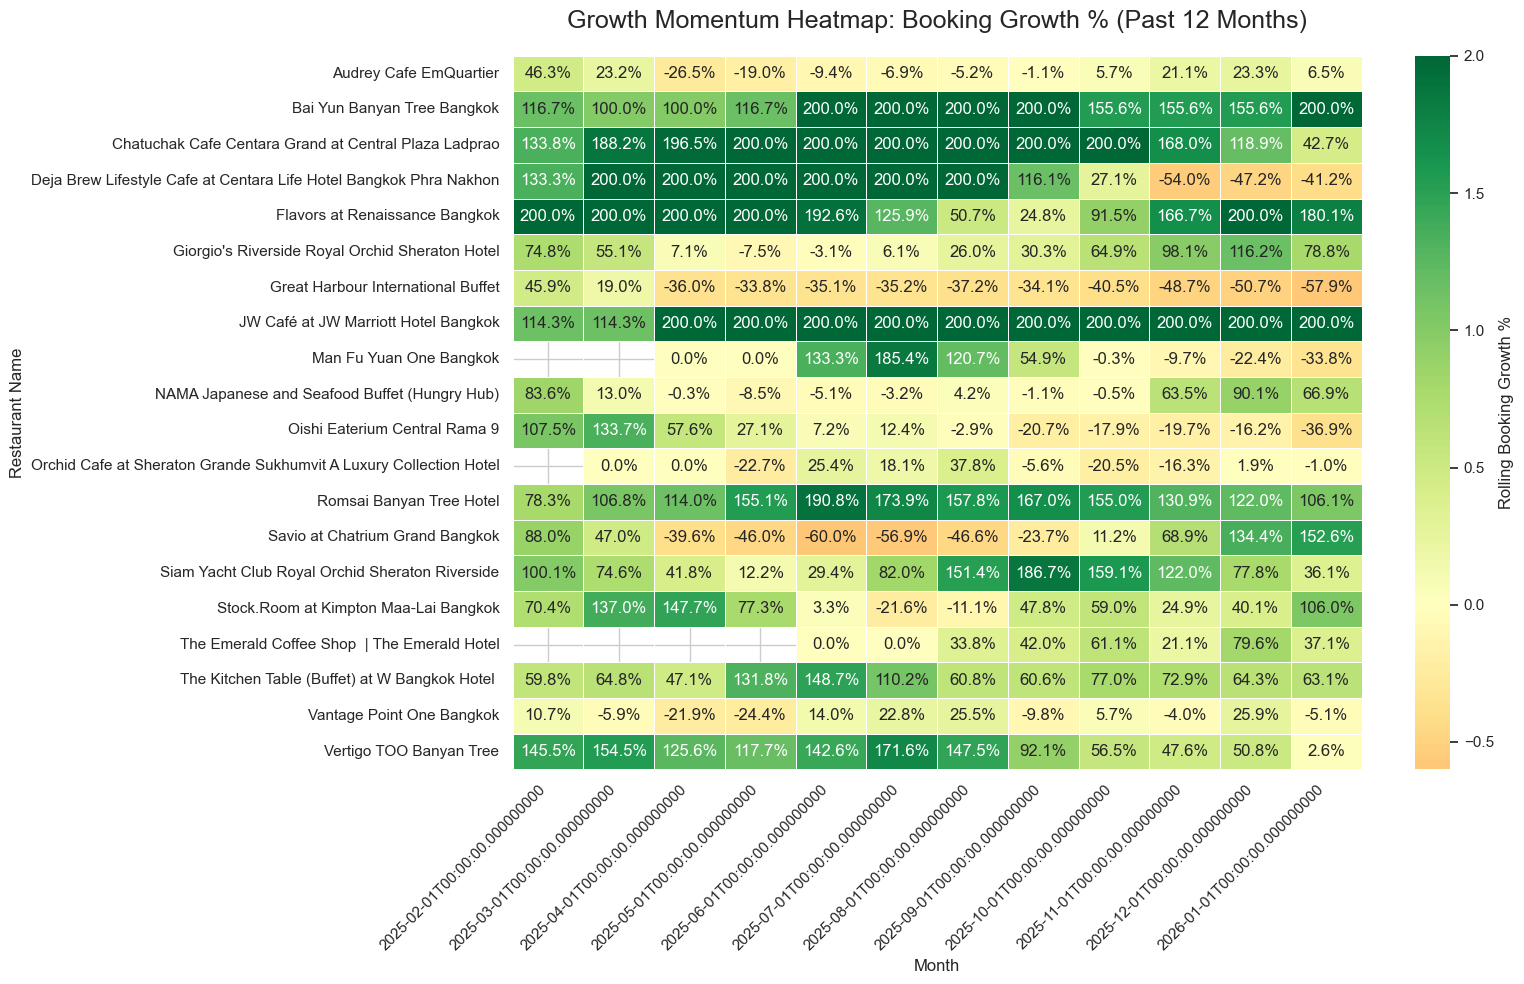

In [28]:
booking_growth_heatmap = growth_trend_df.pivot(
    index='name', 
    columns='year_month', 
    values='booking_growth_rolling'
)

# 4. Plot using a Diverging Color Map (RdYlGn: Red-Yellow-Green)
plt.figure(figsize=(16, 10))
sns.heatmap(
    booking_growth_heatmap, 
    annot=True, 
    fmt=".1%", 
    cmap="RdYlGn", 
    center=0, 
    linewidths=.5,
    cbar_kws={'label': 'Rolling Booking Growth %'}
)

plt.title("Growth Momentum Heatmap: Booking Growth % (Past 12 Months)", fontsize=18, pad=20)
plt.ylabel("Restaurant Name", fontsize=12)
plt.xlabel("Month", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5) Standardize into comparable scores

In [29]:
restaurants_agg_active[['monthly_revenue', 'monthly_bookings', 'booking_growth_rolling', 'revenue_growth_rolling']].describe()

,monthly_revenue,monthly_bookings,booking_growth_rolling,revenue_growth_rolling
count,18334.000000,18334.000000,18334.000000,18334.000000
mean,3743.267192,13.133741,0.179521,0.195614
std,10418.296297,30.624447,0.459045,0.468712
min,18.900000,1.000000,-0.956552,-0.941942
25%,252.000000,1.000000,-0.029027,-0.028565
50%,737.020000,4.000000,0.033333,0.074159
75%,2700.360000,11.000000,0.402778,0.440026
max,199739.520000,447.000000,2.000000,2.000000


In [30]:
# 1. CALIBRATED PERFORMANCE SCORE (Log-Scale is Mandatory)
# ---------------------------------------------------------
# Use Log because Max (447) >> Median (3)
restaurants_agg_active['log_bookings'] = np.log1p(restaurants_agg_active['monthly_bookings'])
restaurants_agg_active['log_rev'] = np.log1p(restaurants_agg_active['monthly_revenue'])

restaurants_agg_active[['log_bookings', 'log_rev']].describe()

,log_bookings,log_rev
count,18334.000000,18334.000000
mean,1.816445,6.798181
std,1.106711,1.609396
min,0.693147,2.990720
25%,0.693147,5.533389
50%,1.609438,6.603971
75%,2.484907,7.901511
max,6.104793,12.204774


In [31]:
# Scale to 0-1
def min_max(s):
    rng = s.max() - s.min()
    if rng == 0:
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / rng

# ── IMPORTANT: Score only on rows within the analysis window ─────────────────
# Prior-year rows were retained for YoY calculation but should NOT influence
# the performance/growth scores — those reflect current standing only.
# We compute scores on the full df (so indices align) but they are only
# meaningful for in_analysis_window rows.
restaurants_agg_active['log_bookings'] = np.log1p(restaurants_agg_active['monthly_bookings'])
restaurants_agg_active['log_rev']      = np.log1p(restaurants_agg_active['monthly_revenue'])

# Performance score — based on analysis window rows only for fair normalisation
analysis_rows = restaurants_agg_active['in_analysis_window']

restaurants_agg_active['score_perf'] = (
    min_max(restaurants_agg_active['log_bookings']) * 0.5 +
    min_max(restaurants_agg_active['log_rev'])      * 0.5
)

# Momentum / growth score
CAP_VALUE = 2.0

restaurants_agg_active['revenue_growth_rolling'] = (
    restaurants_agg_active['revenue_growth_rolling']
    .replace([np.inf], CAP_VALUE).replace([-np.inf], -1.0)
    .fillna(0).clip(upper=CAP_VALUE, lower=-1.0)
)

restaurants_agg_active['booking_growth_rolling'] = (
    restaurants_agg_active['booking_growth_rolling']
    .replace([np.inf], CAP_VALUE).replace([-np.inf], -1.0)
    .fillna(0).clip(upper=CAP_VALUE, lower=-1.0)
)

restaurants_agg_active['score_growth'] = min_max(
    restaurants_agg_active['revenue_growth_rolling'] * 0.5 +
    min_max(restaurants_agg_active['booking_growth_rolling']) * 0.5
)

print(f"Scores computed on all rows — meaningful for analysis window rows ({analysis_rows.sum():,})")
print(restaurants_agg_active[['score_perf', 'score_growth']].describe().round(3))

Scores computed on all rows — meaningful for analysis window rows (11,640)
       score_perf  score_growth
count   18334.000     18334.000
mean        0.310         0.385
std         0.185         0.156
min         0.000         0.000
25%         0.161         0.312
50%         0.271         0.346
75%         0.427         0.464
max         0.986         1.000


In [32]:
restaurants_agg_active

,restaurant_id,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,in_analysis_window,booking_growth_mom,...,has_full_year,booking_growth_pct,revenue_growth_pct,growth_signal_used,booking_growth_rolling,revenue_growth_rolling,log_bookings,log_rev,score_perf,score_growth
0,4800,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,3198.4,456.914286,2.285714,6,False,0.000000,...,True,0.000000,0.000000,MoM,0.000000,0.000000,2.079442,8.070719,0.403750,0.320253
1,4800,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,21789.1,680.909375,3.406250,19,False,2.000000,...,True,2.000000,2.000000,MoM,0.000000,0.000000,3.496508,9.989211,0.638784,0.320253
2,4800,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,12593.7,599.700000,3.000000,17,False,-0.343750,...,True,-0.343750,-0.422018,MoM,0.552083,0.525994,3.091042,9.441031,0.571575,0.501266
3,4800,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,15592.2,742.485714,3.714286,11,False,0.000000,...,True,0.000000,0.238095,MoM,0.552083,0.605359,3.091042,9.654590,0.583164,0.521422
4,4800,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,10594.7,529.735000,2.650000,14,True,-0.047619,...,True,-0.047619,-0.320513,MoM,-0.130456,-0.168145,3.044522,9.268204,0.557899,0.266343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18329,5916,sala ayutthaya staycation (Ayutthaya),2025-06-01,1,468.0,468.000000,2.000000,1,True,0.000000,...,False,0.000000,-0.250000,MoM,0.000000,0.000000,0.693147,6.150603,0.171471,0.320253
18330,5916,sala ayutthaya staycation (Ayutthaya),2025-10-01,1,468.0,468.000000,2.000000,1,True,0.000000,...,False,0.000000,0.000000,MoM,0.000000,-0.083333,0.693147,6.150603,0.171471,0.299089
18331,5917,sala bang pa-in Staycation (Ayutthaya),2025-09-01,2,1560.0,780.000000,3.500000,2,True,0.000000,...,False,0.000000,0.000000,MoM,0.000000,0.000000,1.098612,7.353082,0.274186,0.320253
18332,5917,sala bang pa-in Staycation (Ayutthaya),2025-10-01,1,2496.0,2496.000000,12.000000,1,True,-0.500000,...,False,-0.500000,0.600000,MoM,0.000000,0.000000,0.693147,7.822845,0.262215,0.320253


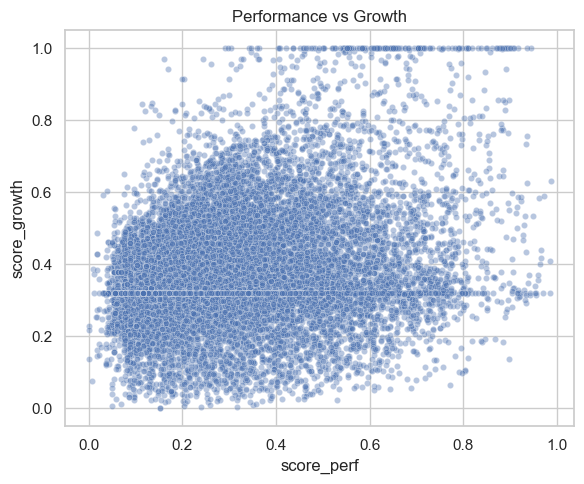

In [33]:
# Performance vs Growth scatter
plt.figure(figsize=(6, 5))
sns.scatterplot(
    data=restaurants_agg_active,
    x="score_perf",
    y="score_growth",
    alpha=0.4,
    s=20
)
plt.title("Performance vs Growth")
plt.tight_layout()

## 6) Composite momentum + segmentation

**Based on latest available record for a restaurant, we obtain their corresponding momentum segment**

However, we need to consider the following that a restaurant may have last available record back in 2024, which will not be useful for us. Would be good to apply a recency filter to remove old records and solely consider more recent ones, e.g. must have booking data within the last 12 months.

In [34]:
# ── Segmentation on analysis-window rows only ────────────────────────────────
# Thresholds and latest snapshot are derived from rows within the analysis
# window so that prior-year rows don't dilute the current picture.

analysis_window_df = restaurants_agg_active[
    restaurants_agg_active['in_analysis_window']
].copy()

# Latest snapshot per restaurant (within analysis window)
latest = analysis_window_df.sort_values("year_month").groupby("name").tail(1)
print(f"Restaurants in latest snapshot: {latest['name'].nunique():,}")

# Thresholds from latest snapshot
perf_threshold   = latest['score_perf'].quantile(0.90)
growth_threshold = latest['score_growth'].quantile(0.90)

print(f"Performance Cutoff (90th%) : {perf_threshold:.3f}")
print(f"Growth Cutoff (90th%)      : {growth_threshold:.3f}")

# Segmentation function
def get_segment(row):
    is_big     = row['score_perf']   >= perf_threshold
    is_growing = row['score_growth'] >= growth_threshold

    if is_big and is_growing:
        return "Rising Stars"
    if not is_big and is_growing:
        return "Emerging Opportunities"
    if is_big and not is_growing:
        return "Established Players"
    return "Needs Attention"

latest['segment'] = latest.apply(get_segment, axis=1)

print("\nSegment distribution:")
print(latest['segment'].value_counts())

Restaurants in latest snapshot: 1,693
Performance Cutoff (90th%) : 0.381
Growth Cutoff (90th%)      : 0.526

Segment distribution:
segment
Needs Attention           1403
Emerging Opportunities     120
Established Players        120
Rising Stars                50
Name: count, dtype: int64


In [35]:
latest

,restaurant_id,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,in_analysis_window,booking_growth_mom,...,booking_growth_pct,revenue_growth_pct,growth_signal_used,booking_growth_rolling,revenue_growth_rolling,log_bookings,log_rev,score_perf,score_growth,segment
8376,3953,MJ Hotpot,2025-01-01,1,426.00,426.00,4.0,1,True,-0.666667,...,-0.666667,-0.798066,MoM,0.222222,0.133696,0.693147,6.056784,0.166380,0.373298,Needs Attention
10823,3975,Patong Bay Hill Resort (Phuket),2025-01-01,2,195.00,97.50,2.0,2,True,1.000000,...,1.000000,1.000000,MoM,0.333333,0.333333,1.098612,5.278115,0.161588,0.433545,Needs Attention
10672,5229,Pae Shabu & Grill House Ramkhamhaeng Housing,2025-01-01,1,71.64,71.64,3.0,1,True,0.000000,...,0.000000,0.000000,MoM,0.000000,0.000000,0.693147,4.285516,0.070262,0.320253,Needs Attention
12843,4429,Shabushi Seacon Square,2025-01-01,2,310.80,155.40,3.5,2,True,-0.500000,...,-0.500000,-0.300000,MoM,0.611111,0.537060,1.098612,5.742362,0.186780,0.509147,Needs Attention
9020,4289,Melody Bangkok,2025-01-01,1,202.80,202.80,4.0,1,True,0.000000,...,0.000000,0.000000,MoM,0.000000,0.000000,0.693147,5.317139,0.126243,0.320253,Needs Attention
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10929,5526,Phrikkhua Kapihom The Nine Tiwanon,2026-01-01,1,133.20,133.20,2.0,1,True,0.000000,...,0.000000,0.000000,MoM,0.166667,0.300000,0.693147,4.899331,0.103571,0.410762,Needs Attention
1605,4335,Bangrak Grill at Grande Centre Point Surawong,2026-01-01,1,203.76,203.76,2.0,1,True,-0.923077,...,-0.875000,-0.894377,YoY,-0.016667,-0.056959,0.693147,5.321839,0.126498,0.304356,Needs Attention
17161,4174,Wagyu Yakiniku Ken,2026-01-01,1,350.64,350.64,2.0,1,True,0.000000,...,-0.916667,-0.947367,YoY,-0.694444,-0.838454,0.693147,5.862608,0.155843,0.047656,Needs Attention
10882,5557,Penthouse Bar + Grill Cocktail Bar at Park Hya...,2026-01-01,2,1132.80,566.40,3.5,2,True,-0.500000,...,-0.500000,-0.104364,MoM,0.287879,0.409882,1.098612,7.033330,0.256834,0.449081,Needs Attention


In [36]:
# Compute month-over-month deltas within the analysis window
# (acceleration signals — how fast is growth itself changing?)
cols_to_shift = [
    'booking_growth_rolling', 'revenue_growth_rolling',  # speed
    'log_bookings', 'log_rev'                            # size
]

for col in cols_to_shift:
    analysis_window_df[f'{col}_prev'] = (
        analysis_window_df.groupby("name")[col]
        .shift(1)
        .fillna(0.0)
    )

# Acceleration (change in growth rate)
analysis_window_df['delta_growth_book'] = (
    analysis_window_df['booking_growth_rolling'] -
    analysis_window_df['booking_growth_rolling_prev']
)
analysis_window_df['delta_growth_rev'] = (
    analysis_window_df['revenue_growth_rolling'] -
    analysis_window_df['revenue_growth_rolling_prev']
)

# Expansion (change in absolute size)
analysis_window_df['delta_size_book'] = (
    analysis_window_df['log_bookings'] - analysis_window_df['log_bookings_prev']
)
analysis_window_df['delta_size_rev'] = (
    analysis_window_df['log_rev'] - analysis_window_df['log_rev_prev']
)

print("Delta columns computed on analysis window.")
print(analysis_window_df[['delta_growth_book', 'delta_growth_rev']].describe().round(3))

Delta columns computed on analysis window.
       delta_growth_book  delta_growth_rev
count          11640.000         11640.000
mean               0.011             0.017
std                0.358             0.386
min               -0.992            -0.994
25%               -0.167            -0.168
50%                0.000             0.000
75%                0.167             0.201
max                1.619             2.000


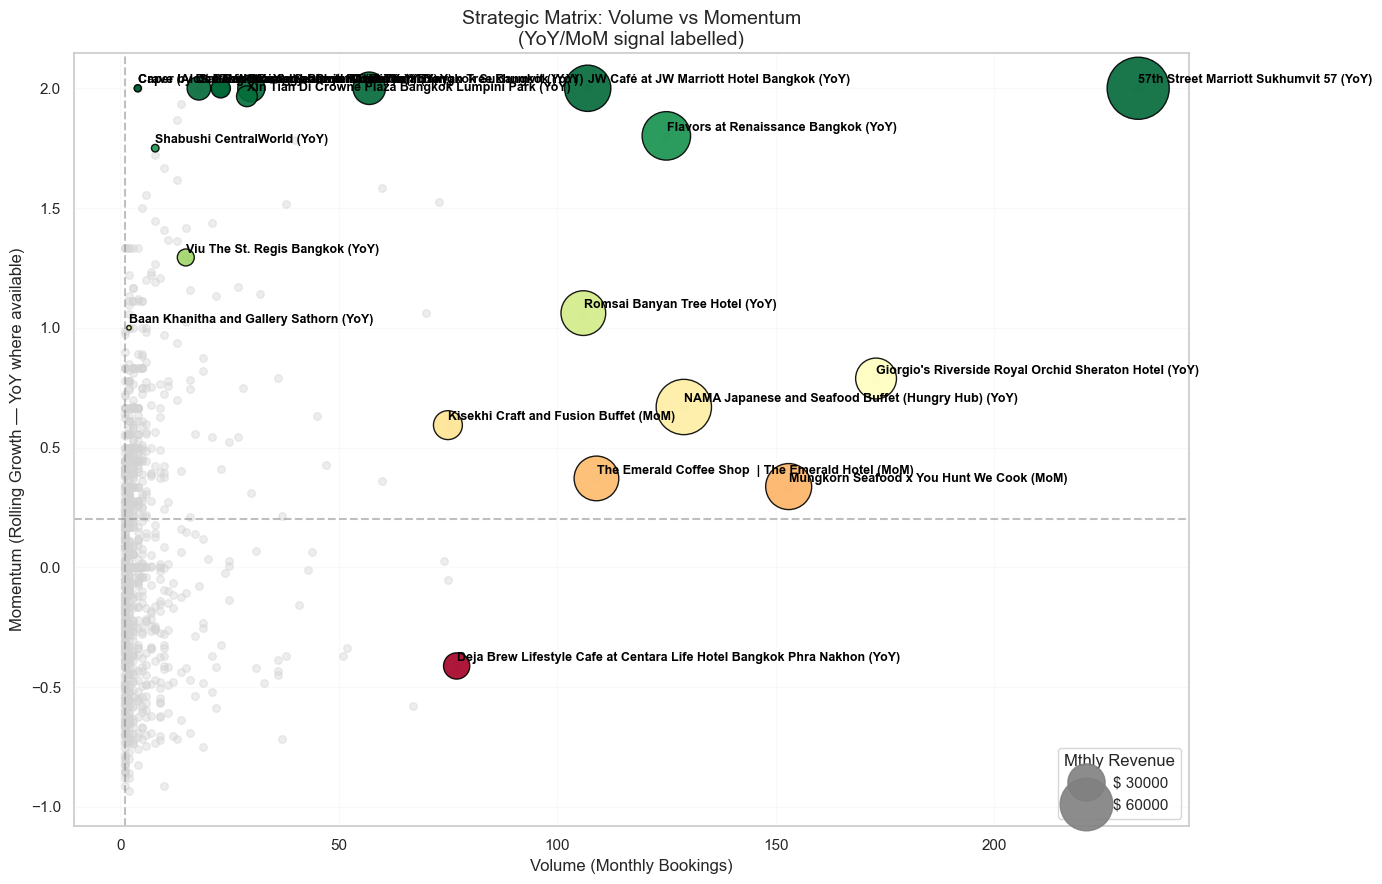

In [37]:
# ── Strategic matrix: Volume vs Momentum (top movers highlighted) ────────────
# Use highlights_df instead of latest to avoid overwriting the segment snapshot
highlights_df = analysis_window_df.sort_values("year_month").groupby("name").tail(1)

top_revenue_growth = highlights_df.nlargest(10, "revenue_growth_rolling")
top_booking_growth = highlights_df.nlargest(10, "booking_growth_rolling")
top_volume         = highlights_df.nlargest(10, "monthly_bookings")

highlights = pd.concat([top_revenue_growth, top_booking_growth, top_volume]).drop_duplicates()

plt.figure(figsize=(14, 9))

plt.scatter(
    highlights_df["monthly_bookings"],
    highlights_df["booking_growth_rolling"],
    c="lightgrey", s=30, alpha=0.4, label="Others"
)

bubble_size = highlights["monthly_revenue"] / highlights["monthly_revenue"].max() * 2000

scatter = plt.scatter(
    highlights["monthly_bookings"],
    highlights["booking_growth_rolling"],
    s=bubble_size,
    c=highlights["booking_growth_rolling"],
    cmap="RdYlGn",
    edgecolors="black",
    alpha=0.9,
    zorder=10
)

for _, row in highlights.iterrows():
    # Annotate with growth signal used so we know if it's YoY or MoM
    signal = row.get("growth_signal_used", "")
    plt.text(
        row["monthly_bookings"] + 0.05,
        row["booking_growth_rolling"] + 0.02,
        f"{row['name']} ({signal})",
        fontsize=9, fontweight="bold", color="black", zorder=11
    )

plt.axhline(0.2, color="gray", linestyle="--", alpha=0.5)
plt.axvline(highlights_df["monthly_bookings"].median(), color="gray", linestyle="--", alpha=0.5)
plt.title("Strategic Matrix: Volume vs Momentum\n(YoY/MoM signal labelled)", fontsize=14)
plt.xlabel("Volume (Monthly Bookings)")
plt.ylabel("Momentum (Rolling Growth — YoY where available)")
plt.grid(True, alpha=0.1)

kw = dict(prop="sizes", num=3, color="grey", fmt="$ {x:.0f}",
          func=lambda s: s / 2000 * highlights["monthly_revenue"].max())
plt.legend(*scatter.legend_elements(**kw), title="Mthly Revenue", loc="lower right")
plt.tight_layout()
plt.show()

In [38]:
restaurants_agg_active

,restaurant_id,name,year_month,monthly_bookings,monthly_revenue,avg_revenue_per_booking,avg_guests,active_days,in_analysis_window,booking_growth_mom,...,has_full_year,booking_growth_pct,revenue_growth_pct,growth_signal_used,booking_growth_rolling,revenue_growth_rolling,log_bookings,log_rev,score_perf,score_growth
0,4800,Charoen Rung Rueang International Buffet MS S...,2024-08-01,7,3198.4,456.914286,2.285714,6,False,0.000000,...,True,0.000000,0.000000,MoM,0.000000,0.000000,2.079442,8.070719,0.403750,0.320253
1,4800,Charoen Rung Rueang International Buffet MS S...,2024-10-01,32,21789.1,680.909375,3.406250,19,False,2.000000,...,True,2.000000,2.000000,MoM,0.000000,0.000000,3.496508,9.989211,0.638784,0.320253
2,4800,Charoen Rung Rueang International Buffet MS S...,2024-11-01,21,12593.7,599.700000,3.000000,17,False,-0.343750,...,True,-0.343750,-0.422018,MoM,0.552083,0.525994,3.091042,9.441031,0.571575,0.501266
3,4800,Charoen Rung Rueang International Buffet MS S...,2024-12-01,21,15592.2,742.485714,3.714286,11,False,0.000000,...,True,0.000000,0.238095,MoM,0.552083,0.605359,3.091042,9.654590,0.583164,0.521422
4,4800,Charoen Rung Rueang International Buffet MS S...,2025-01-01,20,10594.7,529.735000,2.650000,14,True,-0.047619,...,True,-0.047619,-0.320513,MoM,-0.130456,-0.168145,3.044522,9.268204,0.557899,0.266343
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18329,5916,sala ayutthaya staycation (Ayutthaya),2025-06-01,1,468.0,468.000000,2.000000,1,True,0.000000,...,False,0.000000,-0.250000,MoM,0.000000,0.000000,0.693147,6.150603,0.171471,0.320253
18330,5916,sala ayutthaya staycation (Ayutthaya),2025-10-01,1,468.0,468.000000,2.000000,1,True,0.000000,...,False,0.000000,0.000000,MoM,0.000000,-0.083333,0.693147,6.150603,0.171471,0.299089
18331,5917,sala bang pa-in Staycation (Ayutthaya),2025-09-01,2,1560.0,780.000000,3.500000,2,True,0.000000,...,False,0.000000,0.000000,MoM,0.000000,0.000000,1.098612,7.353082,0.274186,0.320253
18332,5917,sala bang pa-in Staycation (Ayutthaya),2025-10-01,1,2496.0,2496.000000,12.000000,1,True,-0.500000,...,False,-0.500000,0.600000,MoM,0.000000,0.000000,0.693147,7.822845,0.262215,0.320253


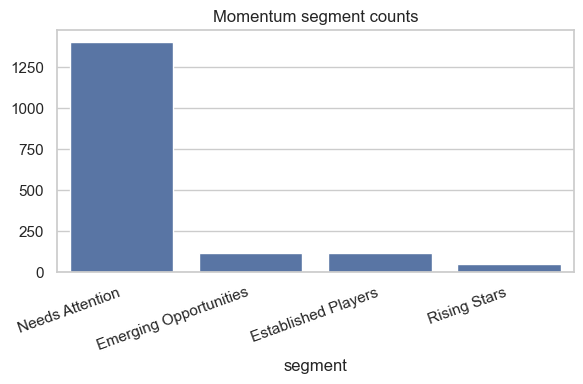

In [39]:
latest['segment'] = latest.apply(get_segment, axis=1)
 # Segment counts
plt.figure(figsize=(6, 4))
segment_counts = latest['segment'].value_counts()
sns.barplot(x=segment_counts.index, y=segment_counts.values)
plt.title("Momentum segment counts")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [40]:
# Save the analysis-window dataframe (scored, with delta columns)
# This is what priority_scoring_seasonality.ipynb reads.
# Prior-year rows were used for YoY but are NOT included in this output —
# the priority scoring notebook only needs current-period signals.
analysis_window_df.to_parquet("restaurants_agg_performance.parquet")
print("Saved restaurants_agg_performance.parquet")
print(f"Shape : {analysis_window_df.shape}")
print(f"Date range : {analysis_window_df['year_month'].min().date()} → {analysis_window_df['year_month'].max().date()}")
print(f"Restaurants: {analysis_window_df['name'].nunique():,}")
print(f"\nNew seasonality columns included:")
seasonality_cols = [c for c in analysis_window_df.columns if any(
    x in c for x in ['yoy', 'mom', 'signal', 'full_year', 'months_of_history', 'in_analysis']
)]
print(seasonality_cols)

Saved restaurants_agg_performance.parquet
Shape : (11640, 32)
Date range : 2025-01-01 → 2026-01-01
Restaurants: 1,693

New seasonality columns included:
['in_analysis_window', 'booking_growth_mom', 'revenue_growth_mom', 'booking_growth_yoy', 'revenue_growth_yoy', 'months_of_history', 'has_full_year', 'growth_signal_used']


## 7) Latest-month prioritised list

In [41]:
# latest_month = restaurants_agg["year_month"].max()
# priority_latest = (
#     restaurants_agg[restaurants_agg["year_month"] == latest_month]
#     .sort_values("momentum_score", ascending=False)
#     .reset_index(drop=True)
# )

# print("Latest month:", latest_month.date())
# print(priority_latest["momentum_segment"].value_counts(dropna=False))
# priority_latest.head(10)

In [42]:
# Save latest-month momentum labels (from analysis window)
output_path = BASE_DIR / "priority_latest_momentum_labels.parquet"
latest.to_parquet(output_path, index=False)
print(f"Saved latest-month momentum labels → {output_path}")
print(f"Restaurants: {latest['name'].nunique():,}")
print(f"Segment distribution:")
print(latest['segment'].value_counts())

Saved latest-month momentum labels → priority_latest_momentum_labels.parquet
Restaurants: 1,693
Segment distribution:
segment
Needs Attention           1403
Emerging Opportunities     120
Established Players        120
Rising Stars                50
Name: count, dtype: int64
